In [1]:
import os
# os.environ["JAX_PLATFORM_NAME"] = "cpu"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import sys

sys.path.insert(0, "../..")

In [2]:
import chex
import dill
import jax
import jax.numpy as jnp
import json
import matplotlib.pyplot as plt
import numpy as np
import optax
import pandas as pd

from flax import nnx
from torch.utils.data import DataLoader
from typing import Any
from typing_extensions import Protocol, runtime_checkable

from src.dataset import get_iter
from src.datasets.sum import Addition
from src.utils import parse_dict

In [3]:
Dtype = Any
Shape = tuple[int, ...]

@runtime_checkable
class HasCache(Protocol):
    def init_cache(self, input_shape: Shape, dtype: Dtype = jnp.float32): ...

def evaluate(learner_path, num_batches, checkpoint_i=-1, stochastic=False):
    config_dict = json.load(open(os.path.join(learner_path, "config.json"), "r"))

    # Load model
    last_step = sorted(os.listdir(os.path.join(learner_path, "models")))[checkpoint_i]
    train_state = dill.load(
        open(os.path.join(learner_path, "models", last_step), "rb")
    )

    # print(train_state.params)
    model = nnx.merge(
        train_state.graphdef,
        train_state.params,
        train_state.rest,
    )

    half_precision = config_dict["half_precision"]
    eval_seed = 42
    batch_size = 1

    dtype = jnp.bfloat16 if half_precision else jnp.float32

    rng = jax.random.PRNGKey(eval_seed)
    rng, rollout_rng = jax.random.split(rng)

    # Get dataset
    dataset_kwargs = parse_dict(config_dict["dataset_kwargs"])
    dataset = Addition(
        dataset_kwargs.context_len * 2,
        dataset_kwargs.max_int,
        True,
        eval_seed,
        # "question_only_decode",
        "question_only",
        # dataset_kwargs.train_val_ratio,
        1.0,
        getattr(dataset_kwargs, "right_to_left", False),
        shuffle=False,
    )
    data_loader = DataLoader(
        dataset,
        batch_size=batch_size,
        num_workers=0,
    )
    data_iter = get_iter(data_loader, None, dtype)

    # Sample next batch and evaluate
    max_decode_len = dataset_kwargs.context_len

    model.eval()
    for _path, m in model.iter_modules():
        if isinstance(m, HasCache):
            input_shape = (
                1,
                max_decode_len,
                config_dict["model_config"]["model_kwargs"]["embed_dim"],
            )
            m.init_cache(input_shape, dtype=dtype)

    graphdef, _, rest = nnx.split(model, nnx.Cache, ...)
    def decode(batch, cache):
        module = nnx.merge(graphdef, cache, rest)
        module.set_attributes(deterministic=True, decode=True)
        out = module(batch)
        cache = nnx.state(module, nnx.Cache)
        return out, cache

    all_res = []
    for _ in range(num_batches):
        batch = next(data_iter)
        cache = nnx.state(model, nnx.Cache)
        preds = []
        logits = []
        rollout_rng = jax.random.split(rollout_rng)[0]
        for step_i in range(max_decode_len):
            # print(batch["sequence"].shape[1])
            # if step_i < batch["sequence"].shape[1]:
            # print(np.where(batch["mask"][0])[0][0] + 1)
            if step_i < np.where(batch["mask"][0])[0][0] + 1:
                res, cache = decode({
                    "sequence": batch["sequence"][:, [step_i]]
                }, cache)
                # print(batch["sequence"][:, [step_i]], res)
            else:
                # print(step_i)
                res, cache = decode({
                    "sequence": preds[-1],
                }, cache)
                # print(res)

            logits.append(res)
            if stochastic:
                preds.append(jax.random.categorical(jax.random.fold_in(rollout_rng, step_i), res))
            else:
                preds.append(jnp.argmax(res, axis=-1))
        all_res.append((batch, preds, logits))
        # print(preds)
    return all_res

In [4]:
base_path = "/home/bryanpu1/projects/iclr_2026/icl_architecture/scaling_jax/results"

# algo_name = "addition"
# run_name = "max_int_8-08-13-25_14_25_20-d8f77477-f3d7-4972-b749-4358930b8829"
# run_name = "cot-max_int_32-08-18-25_14_13_45-0caf324f-9daf-456c-a309-edabd8ee526d"
# run_name = "max_int_32-08-18-25_14_09_01-22351d80-4697-4c8e-bc1b-2095cd04f288"
# run_name = "right_to_left-max_int_32-08-18-25_14_09_30-e7ed1fa3-ca51-493e-b823-3f30cdcacc4a"
# run_name = "gru-cot-max_int_32-08-19-25_11_14_35-c2cd8587-d274-449c-a72f-0020f183466e"
# run_name = "gru-max_int_32-08-19-25_11_15_05-7d3c2ae9-5f86-4c13-a303-193d55dab2ad"
# run_name = "gru-right_to_left-max_int_32-08-19-25_11_15_27-0f476f45-6c4c-45c7-939a-00064327f3ab"

# algo_name = "addition-max_int_1024"
# run_name = "pretrain-09-02-25_08_51_23-9cd58e44-858b-447a-9562-43ae1fdd5104"

algo_name = "addition-debug"
run_name = "ppo-finetuning-right_to_left-no_cot-09-03-25_21_18_11-40204681-70ba-40cb-92a5-b7ff402e093a"
# run_name = "reinforce-finetuning-right_to_left-no_cot-09-03-25_21_18_14-f0cb4ae0-6565-4bc1-b8cd-21795617241d"

learner_path = os.path.join(base_path, algo_name, run_name)
all_res = evaluate(
    learner_path,
    num_batches=16,
    checkpoint_i=-1,
    # checkpoint_i=0,
    # checkpoint_i=3,
    # stochastic=True,
    stochastic=False,
)

In [5]:
for sample_i, (batch, preds, logits) in enumerate(all_res):
    print("Sample: {} ----------------".format(sample_i))

    input_sequence = batch["sequence"].flatten().tolist()
    input_sequence = input_sequence[:input_sequence.index(4)]
    target = batch["target"].flatten().tolist()
    print(".  Input 1: {}".format(input_sequence[:len(input_sequence) // 2][:-1]))
    print(".  Input 2: {}".format(input_sequence[len(input_sequence) // 2:][:-1]))
    print(".   Target: {}".format(target[:target.index(4) + 1][1:-1]))

    pred_trace = jnp.concatenate(preds, axis=-1).flatten()[
        np.where(batch["mask"][0])[0][0]:# batch["sequence"].shape[1] + batch["target"].shape[1]
    ]
    logits = np.array(logits)
    entropies = optax.softmax_cross_entropy(logits, jax.nn.softmax(logits, axis=-1)).flatten()

    # Print the prediction trace
    curr_trace = []
    for output in pred_trace:
        if output == 3 and len(curr_trace) > 0:
            print(".    Trace: {}".format(curr_trace))
            curr_trace = []
        else:
            curr_trace.append(output.item())
        
        if output == 4:
            print("Prediction: {}".format(curr_trace[:-1]))
            break
    else:
        print("Prediction: {}".format(curr_trace[:-1]))
    # print("Entropy: {}".format(entropies))

Sample: 0 ----------------
.  Input 1: [0]
.  Input 2: [0]
.   Target: [0]


Prediction: [0]
Sample: 1 ----------------
.  Input 1: [0]
.  Input 2: [1]
.   Target: [1]
Prediction: [1]
Sample: 2 ----------------
.  Input 1: [1]
.  Input 2: [1]
.   Target: [0, 1]
Prediction: [0, 1]
Sample: 3 ----------------
.  Input 1: [1, 1]
.  Input 2: [0, 1]
.   Target: [1, 0, 1]
Prediction: [1, 0, 1]
Sample: 4 ----------------
.  Input 1: [1, 1]
.  Input 2: [1, 0]
.   Target: [0, 0, 1]
Prediction: [0, 0, 1]
Sample: 5 ----------------
.  Input 1: [0, 1]
.  Input 2: [1, 1]
.   Target: [1, 0, 1]
Prediction: [1, 0, 1]
Sample: 6 ----------------
.  Input 1: [0, 1]
.  Input 2: [0, 0]
.   Target: [0, 1]
Prediction: [0, 1]
Sample: 7 ----------------
.  Input 1: [0, 1]
.  Input 2: [1, 0]
.   Target: [1, 1]
Prediction: [1, 1]
Sample: 8 ----------------
.  Input 1: [0, 0]
.  Input 2: [0, 1]
.   Target: [0, 1]
Prediction: [0, 1]
Sample: 9 ----------------
.  Input 1: [1, 1]
.  Input 2: [1, 1]
.   Target: [0, 1, 1]
Prediction: [0, 1, 1]
Sample: 10 ----------------
.  Input 1: [1]
.  Inpu

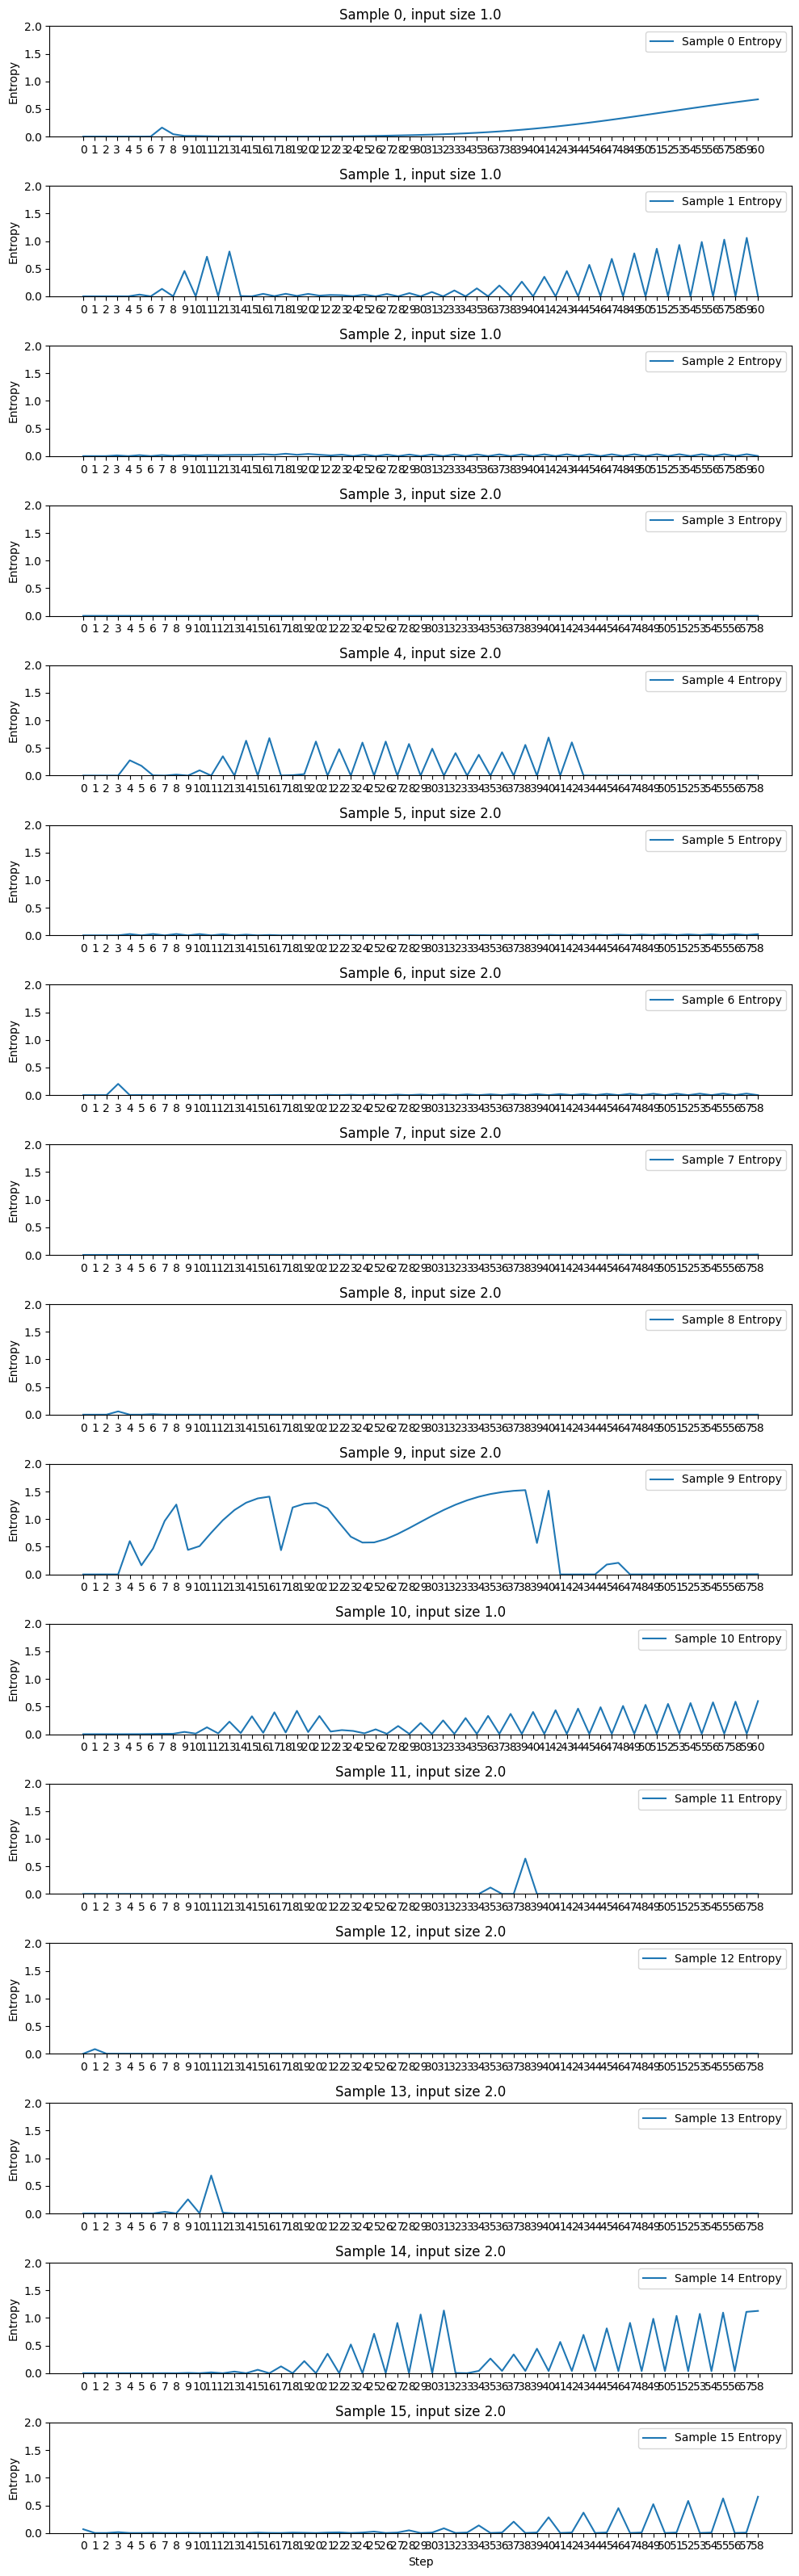

In [6]:
fig, axs = plt.subplots(len(all_res), 1, figsize=(10, 2 * len(all_res)))

for i, (batch, preds, logits) in enumerate(all_res):
    # Compute prediction trace
    pred_trace = jnp.concatenate(preds, axis=-1).flatten()[
        np.where(batch["mask"][0])[0][0]:
    ]
    logits_arr = np.array(logits)
    entropies = optax.softmax_cross_entropy(logits_arr, jax.nn.softmax(logits_arr, axis=-1)).flatten()[
        np.where(batch["mask"][0])[0][0]:# batch["sequence"].shape[1] + batch["target"].shape[1]
    ]

    axs[i].plot(entropies, label=f'Sample {i} Entropy')
    axs[i].set_ylabel('Entropy')
    axs[i].legend(loc='upper right')

    input_sequence = batch["sequence"].flatten()
    input_sequence = input_sequence[:np.where(input_sequence == 4)[0][0]]
    axs[i].set_title(f'Sample {i}, input size {(len(input_sequence) - 2) / 2}')
    axs[i].set_xticks(np.arange(len(entropies)))
    axs[i].set_ylim(0.0, 2.0)

axs[-1].set_xlabel('Step')
plt.tight_layout()
plt.show()